# Chapter 5: The Mechanics of Learning

In [1]:
import torch

t_c = [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0]
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]
t_c = torch.tensor(t_c)
t_u = torch.tensor(t_u)

In [2]:
def model(t_u, w, b):
    return w * t_u + b

We are building a tensor of differences, taking their square element-wise, and finally
producing a scalar loss function by averaging all of the elements in the resulting tensor. It is a mean square loss:

In [3]:
def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c)**2
    return squared_diffs.mean()

 We can now initialize the parameters, invoke the model with:

In [4]:
import torch

w = torch.ones(())
b = torch.zeros(())
t_p = model(t_u, w, b)
t_p

tensor([35.7000, 55.9000, 58.2000, 81.9000, 56.3000, 48.9000, 33.9000, 21.8000,
        48.4000, 60.4000, 68.4000])

In [5]:
loss = loss_fn(t_p, t_c)
loss

tensor(1763.8848)

### The derivatives:

In [6]:
def dloss_fn(t_p, t_c):
    dsq_diffs=2* (t_p - t_c) / t_p.size(0)
    return dsq_diffs

In [7]:
def dmodel_dw(t_u, w, b):
    return t_u

In [8]:
def dmodel_db(t_u, w, b):
    return 1.0

In [9]:
def grad_fn(t_u, t_c, t_p, w, b):
    dloss_dtp = dloss_fn(t_p, t_c)
    dloss_dw = dloss_dtp * dmodel_dw(t_u, w, b)
    dloss_db = dloss_dtp * dmodel_db(t_u, w, b)
    return torch.stack([dloss_dw.sum(), dloss_db.sum()])

The summation in the last line is the reverse of the broadcasting we implicitly do
when applying the parameters to an entire vector of inputs in the model. We use
torch.stack to combine the weights and bias into one tensor because the parameters
are passed in as one tensor, so the resulting gradients should also be a single tensor.

In [10]:
def training_loop(n_epochs, learning_rate, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1):
        w, b = params

        t_p = model(t_u, w, b) # Forward pass
        loss = loss_fn(t_p, t_c)
        grad = grad_fn(t_u, t_c, t_p, w, b) # Backward pass

        params = params - learning_rate * grad
        print('Epoch %d, Loss %f' % (epoch, float(loss)))
    return params

In [11]:
training_loop(
n_epochs = 100,
learning_rate = 1e-2,
params = torch.tensor([1.0, 0.0]),
t_u = t_u,
t_c = t_c)

Epoch 1, Loss 1763.884766
Epoch 2, Loss 5802484.500000
Epoch 3, Loss 19408029696.000000
Epoch 4, Loss 64915905708032.000000
Epoch 5, Loss 217130525461053440.000000
Epoch 6, Loss 726257583152928129024.000000
Epoch 7, Loss 2429183416467662896627712.000000
Epoch 8, Loss 8125122549611731432050262016.000000
Epoch 9, Loss 27176882120842590626938030653440.000000
Epoch 10, Loss 90901105189019073810297959556841472.000000
Epoch 11, Loss inf
Epoch 12, Loss inf
Epoch 13, Loss inf
Epoch 14, Loss inf
Epoch 15, Loss inf
Epoch 16, Loss inf
Epoch 17, Loss inf
Epoch 18, Loss inf
Epoch 19, Loss inf
Epoch 20, Loss inf
Epoch 21, Loss inf
Epoch 22, Loss inf
Epoch 23, Loss nan
Epoch 24, Loss nan
Epoch 25, Loss nan
Epoch 26, Loss nan
Epoch 27, Loss nan
Epoch 28, Loss nan
Epoch 29, Loss nan
Epoch 30, Loss nan
Epoch 31, Loss nan
Epoch 32, Loss nan
Epoch 33, Loss nan
Epoch 34, Loss nan
Epoch 35, Loss nan
Epoch 36, Loss nan
Epoch 37, Loss nan
Epoch 38, Loss nan
Epoch 39, Loss nan
Epoch 40, Loss nan
Epoch 41, Loss

tensor([nan, nan])


#### OVERTRAINING


Wait, what happened? Our training process literally blew up, leading to losses becoming inf. This is a clear sign that params is receiving updates that are too large, and the
values start oscillating back and forth as each update overshoots and the next overcorrects even more. The optimization process is unstable: it diverges instead of converging
to a minimum. We want to see smaller and smaller updates to params, not larger.

We usually change learning rates by orders of magnitude, so we might try with 1e-3 or
1e-4, which would decrease the magnitude of the updates by orders of magnitude.
Let’s go with 1e-4 and see how it works out:

In [12]:
training_loop(
n_epochs = 100,
learning_rate = 1e-4,
params = torch.tensor([1.0, 0.0]),
t_u = t_u,
t_c = t_c)

Epoch 1, Loss 1763.884766
Epoch 2, Loss 323.090515
Epoch 3, Loss 78.929634
Epoch 4, Loss 37.552845
Epoch 5, Loss 30.540283
Epoch 6, Loss 29.351154
Epoch 7, Loss 29.148884
Epoch 8, Loss 29.113848
Epoch 9, Loss 29.107145
Epoch 10, Loss 29.105247
Epoch 11, Loss 29.104168
Epoch 12, Loss 29.103222
Epoch 13, Loss 29.102295
Epoch 14, Loss 29.101379
Epoch 15, Loss 29.100466
Epoch 16, Loss 29.099548
Epoch 17, Loss 29.098631
Epoch 18, Loss 29.097717
Epoch 19, Loss 29.096796
Epoch 20, Loss 29.095881
Epoch 21, Loss 29.094959
Epoch 22, Loss 29.094049
Epoch 23, Loss 29.093134
Epoch 24, Loss 29.092216
Epoch 25, Loss 29.091301
Epoch 26, Loss 29.090385
Epoch 27, Loss 29.089464
Epoch 28, Loss 29.088551
Epoch 29, Loss 29.087635
Epoch 30, Loss 29.086714
Epoch 31, Loss 29.085804
Epoch 32, Loss 29.084888
Epoch 33, Loss 29.083967
Epoch 34, Loss 29.083057
Epoch 35, Loss 29.082142
Epoch 36, Loss 29.081221
Epoch 37, Loss 29.080309
Epoch 38, Loss 29.079390
Epoch 39, Loss 29.078474
Epoch 40, Loss 29.077562
Epoch 

tensor([ 0.2327, -0.0438])

Nice—the behavior is now stable. But there’s another problem: the updates to parameters are very small, so the loss decreases very slowly and eventually stalls. We could
obviate this problem by making learning_rate adaptive—that is, change according to
the magnitude of updates.

There are optimization schemes that do that, and we’ll see
one toward the end of this chapter, in section 5.5.2.
 However, there’s another potential troublemaker in the update term: the gradient
itself. Let’s go back and look at grad at epoch 1 during optimization.


### Normalizing inputs
We can see that the first-epoch gradient for the weight is about 50 times larger than
the gradient for the bias. Thus, the weight and bias live in differently scaled spaces. If
this is the case, a learning rate that’s large enough to meaningfully update one will be
so large as to be unstable for the other, and a rate that’s appropriate for the other
won’t be large enough to meaningfully change the first. So, we’re not going to be able
to update our parameters unless we change something about our formulation of the
problem. We could have individual learning rates for each parameter, but for models
with many parameters, this method would be too much to bother with; it’s babysitting
of the kind we don’t like.

 There’s a simpler way to keep things in check: changing the inputs so that the gradients aren’t quite so different. We can make sure the range of the input doesn’t get
too far from the range of –1.0 to 1.0, roughly speaking. In our case, we can achieve
something close enough to that by simply multiplying t_u by 0.1:

In [13]:
t_un = 0.1 * t_u

In [14]:
training_loop(
n_epochs = 100,
learning_rate = 1e-2,
params = torch.tensor([1.0, 0.0]),
t_u = t_un, # We updated t_u to our new, rescaled t_un
t_c = t_c)

Epoch 1, Loss 80.364342
Epoch 2, Loss 37.574913
Epoch 3, Loss 30.871077
Epoch 4, Loss 29.756193
Epoch 5, Loss 29.507153
Epoch 6, Loss 29.392456
Epoch 7, Loss 29.298828
Epoch 8, Loss 29.208717
Epoch 9, Loss 29.119415
Epoch 10, Loss 29.030489
Epoch 11, Loss 28.941877
Epoch 12, Loss 28.853565
Epoch 13, Loss 28.765553
Epoch 14, Loss 28.677851
Epoch 15, Loss 28.590431
Epoch 16, Loss 28.503319
Epoch 17, Loss 28.416498
Epoch 18, Loss 28.329973
Epoch 19, Loss 28.243742
Epoch 20, Loss 28.157804
Epoch 21, Loss 28.072151
Epoch 22, Loss 27.986797
Epoch 23, Loss 27.901728
Epoch 24, Loss 27.816950
Epoch 25, Loss 27.732464
Epoch 26, Loss 27.648256
Epoch 27, Loss 27.564344
Epoch 28, Loss 27.480707
Epoch 29, Loss 27.397362
Epoch 30, Loss 27.314295
Epoch 31, Loss 27.231512
Epoch 32, Loss 27.149010
Epoch 33, Loss 27.066790
Epoch 34, Loss 26.984844
Epoch 35, Loss 26.903175
Epoch 36, Loss 26.821791
Epoch 37, Loss 26.740679
Epoch 38, Loss 26.659838
Epoch 39, Loss 26.579279
Epoch 40, Loss 26.498987
Epoch 41,

tensor([ 2.7553, -2.5162])

Even though we set our learning rate back to 1e-2, parameters don’t blow up during
iterative updates. Let’s take a look at the gradients: they’re of similar magnitude, so
using a single learning_rate for both parameters works just fine. We could probably
do a better job of normalization than a simple rescaling by a factor of 10, but since
doing so is good enough for our needs, we’re going to stick with that for now.

NOTE The normalization here absolutely helps get the network trained, but
you could make an argument that it’s not strictly needed to optimize the
parameters for this particular problem. That’s absolutely true! This problem
is small enough that there are numerous ways to beat the parameters into submission. However, for larger, more sophisticated problems, normalization is
an easy and effective (if not crucial!) tool to improve model convergence.

In [15]:
params = training_loop(
n_epochs = 5000,
learning_rate = 1e-2,
params = torch.tensor([1.0, 0.0]),
t_u = t_un,
t_c = t_c)
params

Epoch 1, Loss 80.364342
Epoch 2, Loss 37.574913
Epoch 3, Loss 30.871077
Epoch 4, Loss 29.756193
Epoch 5, Loss 29.507153
Epoch 6, Loss 29.392456
Epoch 7, Loss 29.298828
Epoch 8, Loss 29.208717
Epoch 9, Loss 29.119415
Epoch 10, Loss 29.030489
Epoch 11, Loss 28.941877
Epoch 12, Loss 28.853565
Epoch 13, Loss 28.765553
Epoch 14, Loss 28.677851
Epoch 15, Loss 28.590431
Epoch 16, Loss 28.503319
Epoch 17, Loss 28.416498
Epoch 18, Loss 28.329973
Epoch 19, Loss 28.243742
Epoch 20, Loss 28.157804
Epoch 21, Loss 28.072151
Epoch 22, Loss 27.986797
Epoch 23, Loss 27.901728
Epoch 24, Loss 27.816950
Epoch 25, Loss 27.732464
Epoch 26, Loss 27.648256
Epoch 27, Loss 27.564344
Epoch 28, Loss 27.480707
Epoch 29, Loss 27.397362
Epoch 30, Loss 27.314295
Epoch 31, Loss 27.231512
Epoch 32, Loss 27.149010
Epoch 33, Loss 27.066790
Epoch 34, Loss 26.984844
Epoch 35, Loss 26.903175
Epoch 36, Loss 26.821791
Epoch 37, Loss 26.740679
Epoch 38, Loss 26.659838
Epoch 39, Loss 26.579279
Epoch 40, Loss 26.498987
Epoch 41,

tensor([  5.3671, -17.3012])

Good, our loss decreases while we change parameters along the direction of gradient
descent. It doesn’t go exactly to zero; this result could mean that there aren’t enough
iterations to converge to zero or that the data points don’t sit exactly on a line. As we
anticipated, our measurements were not perfectly accurate, or there was noise
involved in the reading.

 But look: the values for w and b look an awful lot like the numbers we need to use to
convert Fahrenheit to Celsius. We had our model learn the relationship C=w*unknown + b,
and from science, we know the exact formula to be C = (F - 32) * 5/9, which simplifies
to C = (5/9) * F - (32 * 5 / 9) to give us exact values w=.55556 and b=-17.7778. Multiply w by 10 to account for our earlier normalization when we multiplied our inputs by
0.1 and our model parameters are pretty close to the expected w and b. Our fancy thermometer was showing temperatures in Fahrenheit the whole time. No big discovery,
except that our gradient descent optimization process works!

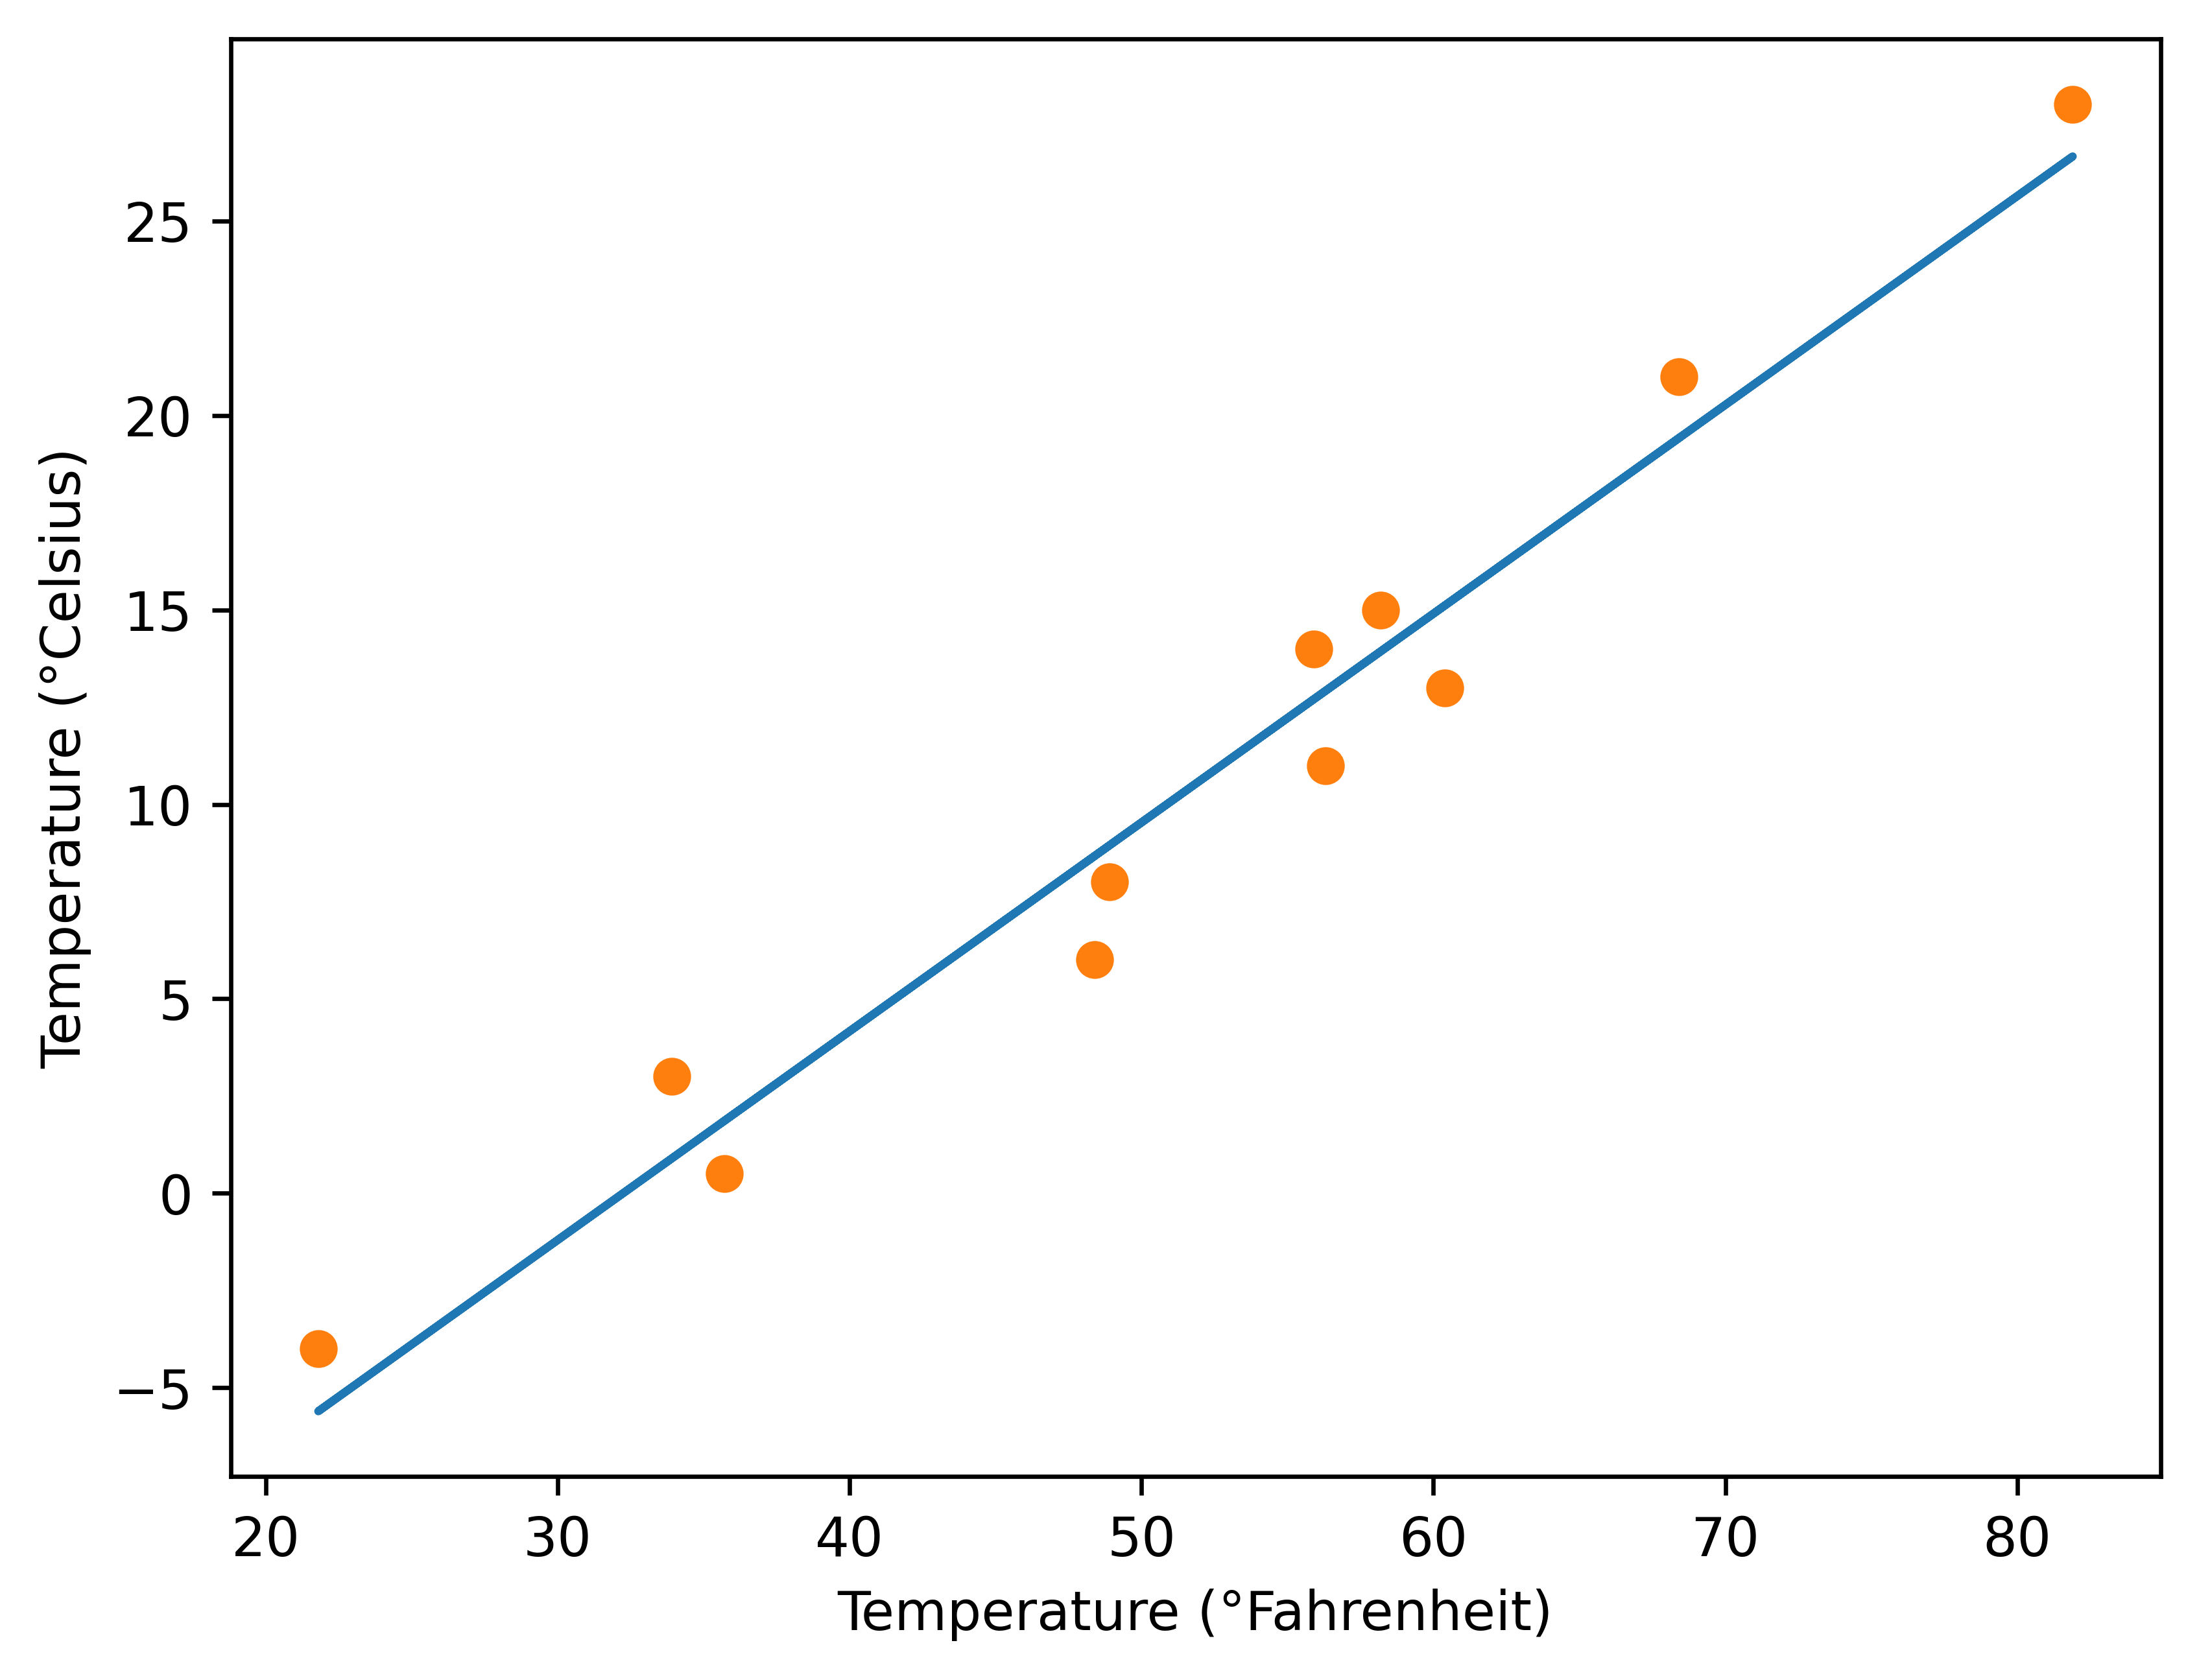

In [16]:
%matplotlib inline
from matplotlib import pyplot as plt

# Remember that we’re training on the normalized unknown units. We also use argument unpacking.
t_p = model(t_un, *params)
fig = plt.figure(dpi=600)
plt.xlabel("Temperature (°Fahrenheit)")
plt.ylabel("Temperature (°Celsius)")
plt.plot(t_u.numpy(), t_p.detach().numpy())
plt.plot(t_u.numpy(), t_c.numpy(), 'o')

We are using a Python trick called argument unpacking here: *params means to pass
the elements of params as individual arguments. In Python, this is usually done with
lists or tuples, but we can also use argument unpacking with PyTorch tensors, which
are split along the leading dimension. So here, model(t_un, *params) is equivalent to
model(t_un, params[0], params[1]).

 This code produces figure 5.9. Our linear model is a good model for the data, it
seems. It also seems our measurements are somewhat erratic.

Computing the gradient automatically with AutoGrad

In [17]:
params = torch.tensor([1.0, 0.0], requires_grad=True)


#### USING THE GRAD ATTRIBUTE
Notice the requires_grad=True argument to the tensor constructor? That argument is
telling PyTorch to track the entire family tree of tensors resulting from operations on
params. In other words, any tensor that will have params as an ancestor will have access
to the chain of functions that were called to get from params to that tensor. In case
these functions are differentiable (and most PyTorch tensor operations will be), the
value of the derivative will be automatically populated as a grad attribute of the params
tensor.

 In general, all PyTorch tensors have an attribute named grad. Normally, it’s None:

In [18]:
params.grad is None

True

All we have to do to populate it is to start with a tensor with requires_grad set to True,
then call the model and compute the loss, and finally call backward on the loss tensor:

In [19]:
loss = loss_fn(model(t_u, *params), t_c)
loss.backward()

params.grad

tensor([4517.2969,   82.6000])

At this point, the grad attribute of params contains the derivatives of the loss with
respect to each element of params.

 When we compute our loss while the parameters w and b require gradients, in
addition to performing the actual computation, PyTorch creates what’s called a computation graph.  When we call loss.backward(),
PyTorch traverses this graph in the reverse direction to compute the gradients, as
shown by the arrows in the bottom row of the figure.

let’s see what our autograd-enabled
training code looks like, start to finish:

In [24]:
def training_loop(n_epochs, learning_rate, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1):
        # This could be done at any point in the loop prior to calling loss.backward().
        if params.grad is not None:
            params.grad.zero_()

        t_p = model(t_u, *params)
        loss = loss_fn(t_p, t_c)
        loss.backward()

        # This is a somewhat cumbersome bit of code, but as we’ll see in the
        # next section,it’s not an issue in practice.
        with torch.no_grad():
            params -= learning_rate * params.grad

        loss_scalar = float(loss.detach())
        if epoch % 500 == 0:
            print('Epoch %d, Loss %f' % (epoch, loss_scalar))
    return params

Note that our code updating params is not quite as straightforward as we might have
expected. There are two particularities.

First, we are encapsulating the update in a
no_grad context using the Python with statement. So, within the with block, the
PyTorch autograd mechanism should look away — that is, not add edges to the forward
graph (in reality, it will track that something changed params using an in-place operation). In fact, when we are executing this bit of code, the forward graph that PyTorch
records is consumed when we call backward, leaving us with the params leaf node. But
now we want to change this leaf node before we start building a fresh forward graph
on top of it.

 Second, we update params in place. We keep the same params tensor around but
subtract our update from it. When using autograd, we usually avoid in-place updates
because PyTorch’s autograd engine might need the values we would be modifying for
the backward pass. Here, however, we are operating within the torch.no_grad() context where autograd tracking is disabled for the parameter update, so it’s safe to modify the params tensor in place.
 Let’s see if it works:

In [25]:
training_loop(
n_epochs = 5000,
learning_rate = 1e-2,
params = torch.tensor([1.0, 0.0], requires_grad=True), # Must set requires_grad=True to enable autograd.
t_u = t_un,
t_c = t_c)

Epoch 500, Loss 7.860115
Epoch 1000, Loss 3.828538
Epoch 1500, Loss 3.092191
Epoch 2000, Loss 2.957698
Epoch 2500, Loss 2.933134
Epoch 3000, Loss 2.928648
Epoch 3500, Loss 2.927830
Epoch 4000, Loss 2.927679
Epoch 4500, Loss 2.927652
Epoch 5000, Loss 2.927647


tensor([  5.3671, -17.3012], requires_grad=True)

The result is the same as we got previously. Good for us! It means that while we are
capable of computing derivatives by hand, we no longer need to.

### Optimizers:

In [26]:
import torch.optim as optim
dir(optim)

['ASGD',
 'Adadelta',
 'Adafactor',
 'Adagrad',
 'Adam',
 'AdamW',
 'Adamax',
 'LBFGS',
 'Muon',
 'NAdam',
 'Optimizer',
 'RAdam',
 'RMSprop',
 'Rprop',
 'SGD',
 'SparseAdam',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_adafactor',
 '_functional',
 '_muon',
 '_stateless',
 'lr_scheduler',
 'swa_utils',
 'swap_in_optimizer_params_and_state']

#### USING A GRADIENT DESCENT OPTIMIZER

In [27]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-5
optimizer = optim.SGD([params], lr=learning_rate)

Here SGD stands for stochastic gradient descent. Actually, the optimizer itself is exactly a
vanilla gradient descent (as long as the momentum argument is set to 0.0, which is the
default). The term stochastic comes from the fact that the gradient is typically obtained
by averaging over a random subset of all input samples, called a minibatch. However, the
optimizer does not know if the loss was evaluated on all the samples (vanilla) or a random subset of them (stochastic), so the algorithm is literally the same in the two cases.

In [28]:
t_p = model(t_u, *params)
loss = loss_fn(t_p, t_c)
loss.backward()
optimizer.step()

params

tensor([ 9.5483e-01, -8.2600e-04], requires_grad=True)

The value of params is updated upon calling step without us having to touch it ourselves! What happens is that the optimizer looks into params.grad and updates params,
subtracting learning_rate times grad from it, exactly as in our former hand-rolled code.
 Ready to stick this code in a training loop? Nope! The big gotcha almost got us—
we forgot to zero out the gradients. Had we called the previous code in a loop, gradients would have accumulated in the leaves at every call to backward, and our gradient
descent would have been all over the place! Here’s the loop-ready code, with the extra
zero_grad at the correct spot (right before the call to backward):

In [29]:


t_p = model(t_u, *params)
loss = loss_fn(t_p, t_c)

# Must zero grads before running backward, because backward accumulates the gradients on the leaves.
optimizer.zero_grad()

loss.backward()
optimizer.step()

params

tensor([ 0.9123, -0.0016], requires_grad=True)

Perfect! See how the optim module helps us abstract away the specific optimization
scheme? All we have to do is provide a list of params to it (that list can be extremely
long, as is needed for very deep neural network models), and we can forget about
the details.
 Let’s update our training loop accordingly:

In [30]:
def training_loop(n_epochs, optimizer, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1):
        t_p = model(t_u, *params)
        loss = loss_fn(t_p, t_c)

        optimizer.zero_grad() # Zero out the gradients before running backward.
        loss.backward()     # Compute gradients of all the inputs with respect to the loss
                            # using backpropagation.

        optimizer.step()    # Optimizer adjusts the parameters in-place using the computed gradients
                            # (and learning rate) to step in the direction of the gradient that
                            # minimizes the loss.
        if epoch % 500 == 0:
            print('Epoch %d, Loss %f' % (epoch, float(loss)))
    return params

In [32]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-2
optimizer = optim.SGD([params], lr=learning_rate)

training_loop(
n_epochs = 5000,
optimizer = optimizer,
params = params,
t_u = t_un,
t_c = t_c)

Epoch 500, Loss 7.860115
Epoch 1000, Loss 3.828538
Epoch 1500, Loss 3.092191
Epoch 2000, Loss 2.957698
Epoch 2500, Loss 2.933134
Epoch 3000, Loss 2.928648
Epoch 3500, Loss 2.927830
Epoch 4000, Loss 2.927679
Epoch 4500, Loss 2.927652
Epoch 5000, Loss 2.927647


tensor([  5.3671, -17.3012], requires_grad=True)

Again, we get the same result as before. Great! This is further confirmation that we
know how to descend a gradient by hand!

Other optimizers:
We won’t go into much detail about Adam; suffice to say that it is a more sophisticated optimizer in which the learning rate is set adaptively. In addition, it is a lot less
sensitive to the scaling of the parameters—so insensitive that we can go back to using
the original (nonnormalized) input t_u, and even increase the learning rate to 1e-1,
and Adam won’t even blink:

In [33]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-1
optimizer = optim.Adam([params], lr=learning_rate)

training_loop(
n_epochs = 2000,
optimizer = optimizer,
params = params,
t_u = t_u,  # Set to original, unnormalized input.
t_c = t_c)

Epoch 500, Loss 7.612898
Epoch 1000, Loss 3.086700
Epoch 1500, Loss 2.928579
Epoch 2000, Loss 2.927644


tensor([  0.5367, -17.3021], requires_grad=True)

The results are the same. However, the first parameter no longer needs to be rescaled since the input was not normalized to begin with in this training set.

The optimizer is not the only flexible part of our training loop. Let’s turn our attention to the model. To train a neural network on the same data and the same loss, we
only need to change the model function. It wouldn’t make particular sense in this case,
since we know that converting Celsius to Fahrenheit amounts to a linear transformation, but we’ll do it anyway in chapter 6. We’ll see quite soon that neural networks
allow us to remove our arbitrary assumptions about the shape of the function we
should be approximating. Even so, we’ll see how neural networks manage to be
trained even when the underlying processes are highly nonlinear (such as in the case
of describing an image with a sentence, as we saw in chapter 2).

 We have touched on a lot of the essential concepts that will enable us to train complicated deep learning models while knowing what’s going on under the hood: backpropagation to estimate gradients, autograd, and optimizing weights of models using
gradient descent or other optimizers. Really, there isn’t a lot more. The rest is mostly
filling in the blanks, however extensive they are.


### SPLITTING A DATASET
Shuffling the elements of a tensor amounts to finding a permutation of its indices.
The randperm function does exactly this:

In [39]:
n_samples = t_u.shape[0]
n_val = int(0.2 * n_samples)

shuffled_indices = torch.randperm(n_samples)
train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]

train_indices, val_indices

(tensor([ 3,  2,  5,  0,  4,  1,  8, 10,  7]), tensor([9, 6]))

We just got index tensors that we can use to build training and validation sets starting
from the data tensors:

In [40]:
train_t_u = t_u[train_indices]
train_t_c = t_c[train_indices]

val_t_u = t_u[val_indices]
val_t_c = t_c[val_indices]

train_t_un = 0.1 * train_t_u
val_t_un = 0.1 * val_t_u

Our training loop doesn’t really change. We just want to evaluate the validation loss at
every epoch to have a chance to recognize whether we’re overfitting:

In [41]:
def training_loop(n_epochs, optimizer, params, train_t_u, val_t_u,
train_t_c, val_t_c):
    for epoch in range(1, n_epochs + 1):
        train_t_p = model(train_t_u, *params)
        train_loss = loss_fn(train_t_p, train_t_c)

        val_t_p = model(val_t_u, *params)
        val_loss = loss_fn(val_t_p, val_t_c)

        optimizer.zero_grad()
        train_loss.backward()   # There is no need to call backward() on val_loss since we only
                                # train on train_t_p.
        optimizer.step()

        if epoch <= 3 or epoch % 500 == 0:
            print(f"Epoch {epoch}, Training loss {train_loss.item():.4f},"
        f" Validation loss {val_loss.item():.4f}")
    return params

In [42]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-2

optimizer = optim.SGD([params], lr=learning_rate)
# Since we are using GD, we need to use the normalized inputs.

training_loop(
n_epochs = 3000,
optimizer = optimizer,
params = params,
train_t_u = train_t_un,
val_t_u = val_t_un,
train_t_c = train_t_c,
val_t_c = val_t_c)

Epoch 1, Training loss 92.8238, Validation loss 24.2968
Epoch 2, Training loss 41.4546, Validation loss 7.2096
Epoch 3, Training loss 34.3515, Validation loss 10.2757
Epoch 500, Training loss 8.0515, Validation loss 2.1452
Epoch 1000, Training loss 3.4542, Validation loss 2.9397
Epoch 1500, Training loss 2.6258, Validation loss 4.3778
Epoch 2000, Training loss 2.4765, Validation loss 5.1867
Epoch 2500, Training loss 2.4496, Validation loss 5.5659
Epoch 3000, Training loss 2.4448, Validation loss 5.7332


tensor([  5.5790, -18.4106], requires_grad=True)

Here, we are not being entirely fair to our model. The validation set is really small, so
the validation loss will only be meaningful up to a point. In any case, we note that the
validation loss is higher than our training loss, although not by an order of magnitude. We expect a model to perform better on the training set, since the model
parameters are being shaped by the training set. Our main goal is to also see both the
training loss and the validation loss decreasing. While ideally both losses would be
roughly the same value, as long as the validation loss stays reasonably close to the
training loss, we know that our model is continuing to learn generalized things about
our data.